In [86]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


# brute force calculation of every single ion coupling to every single mode -- radial only

In [87]:
N = np.arange(3,4)
P = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N3= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P,
    w0,
    max_tweezed=1,
)
result = build_mode_series_and_combinations(N3)
mode0_list = result["mode_lists"][0]
print(mode0_list)
mode1_list = result["mode_lists"][1]
print(mode1_list)
mode2_list = result["mode_lists"][2]
print(mode2_list)

untweezed = combine_lists(mode0_list, mode1_list, mode2_list)[np.nan]
tweeze0 = combine_lists(mode0_list, mode1_list, mode2_list)[0]
tweeze1 = combine_lists(mode0_list, mode1_list, mode2_list)[1]
tweeze2 = combine_lists(mode0_list, mode1_list, mode2_list)[2]

min_untweezed = condense_by_min_abs(untweezed)
min_tweeze_0 = condense_by_min_abs(tweeze0)
min_tweeze_1 = condense_by_min_abs(tweeze1)
min_tweeze_2 = condense_by_min_abs(tweeze2)

best_untweezed = filter_by_max_min_abs(min_untweezed)
best_tweeze_0 = filter_by_max_min_abs(min_tweeze_0)
best_tweeze_1 = filter_by_max_min_abs(min_tweeze_1)
best_tweeze_2 = filter_by_max_min_abs(min_tweeze_2)
print(best_tweeze_0)
print(best_tweeze_1)
print(best_tweeze_2)
select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2])
print(select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2]))


[(nan, array([0.57735027, 0.57735027, 0.57735027])), (0, array([-0.99975899, -0.0217139 , -0.00323688])), (1, array([0.02254184, 0.99949174, 0.02254184])), (2, array([0.00323688, 0.0217139 , 0.99975899]))]
[(nan, array([ 7.07106781e-01, -1.76373406e-13, -7.07106781e-01])), (0, array([-0.01451165,  0.54298991,  0.83961382])), (1, array([ 0.70674738, -0.03187897,  0.70674738])), (2, array([-0.83961382, -0.54298991,  0.01451165]))]
[(nan, array([-0.40824829,  0.81649658, -0.40824829])), (0, array([ 0.0164737 , -0.83945844,  0.54317415])), (1, array([-7.07106781e-01, -1.83901055e-14,  7.07106781e-01])), (2, array([ 0.54317415, -0.83945844,  0.0164737 ]))]
[(0, (0, 2, 1), -0.8394584355453282)]
[(1, (1, 0, 2), 0.7067473845006338)]
[(2, (2, 0, 1), -0.8394584355453685)]
[(0, (0, 2, 1), -0.8394584355453282), (2, (2, 0, 1), -0.8394584355453685)]


In [88]:
def run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.
    
    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index)), ...]
    """
    
    # 1. Build eigenvector lists for all configurations
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=max_tweezed
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- CLEAN: remove unusable keys ----
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v
    mode_lists_dict = cleaned
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices and collect all mode lists
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))

    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 3. Combine modes across all tweezed ions
    combos = combine_lists(*mode_lists_ordered)
    
    # 4. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 5. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 6. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))

  # 7. Compute best ion/mode indices properly
    augmented = []
    for tweezed_ion, mapping, score in winners:
        # Access the corresponding values from combos
        values = None
        for t, combo_indices, arr in combos[tweezed_ion]:
            if combo_indices == mapping:
                values = arr
                break
        
        if values is None:
            # fallback: use mapping itself (less accurate)
            values = np.array(mapping)
        
        # best ion index = position in vector responsible for min(abs) (i.e., score)
        best_ion_index = int(np.argmin(np.abs(values)))
        best_mode_index = mapping[best_ion_index]

        # ✅ ADD P_opt BACK INTO THE RETURNED STRUCTURE
        augmented.append(
            ((tweezed_ion, mapping, score, P_opt), (best_ion_index, best_mode_index))
        )

    return augmented





import numpy as np
import math

def run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
):
    """
    Run optimal mode selection for the untweezed configuration only.
    
    Returns:
        winners: list of tuples
                 [(None, ion_to_mode_mapping, max_of_min_abs), ...]
    """
    
    # 1. Build eigenvector lists for the untweezed configuration
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=0
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- FIX SECTION ----
    # remove unusable keys (nan, None, empty tuples)
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v

    mode_lists_dict = cleaned
    # ---- END FIX ----
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices numerically if possible
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        # fallback: sort by string representation
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))
    
    if not mode_indices:
        return []
    
    # 3. Collect lists in canonical order
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 4. Combine modes
    combos = combine_lists(*mode_lists_ordered)
    
    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 6. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    
    # 8. Add placeholder for "none tweezed"
    winners = [(None, combo, val) for _, combo, val in winners]

    #can remove this later but this is just to make sure it all works
    print("Keys:", list(mode_lists_dict.keys()))
    
    return winners




DO NOT NAME ANYTHING ELSE RESULTS OR UNTWEEZED RESULTS OR TRY TO RUN THE CODE BLOCK UNDERNEATH THIS AGAIN. BOTH OF THEM TAKE LIKE 20 MINUTES

In [89]:
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results.append((Ni, winners))


In [90]:
Power = [100]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results_high_P = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        Power,
        w0,
        max_tweezed=1,
    )
    results_high_P.append((Ni, winners))

In [91]:
untweezed_results = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))


Keys: [0, 1]
Keys: [0, 1, 2]
Keys: [0, 1, 2, 3]
Keys: [0, 1, 2, 3, 4]
Keys: [0, 1, 2, 3, 4, 5]
Keys: [0, 1, 2, 3, 4, 5, 6]


In [92]:
results

[(2,
  [((0, (0, 1), 0.9999048485013973, [0.1]), (0, 0)),
   ((1, (1, 0), 0.9999048485013973, [0.1]), (0, 1))]),
 (3,
  [((0, (0, 2, 1), -0.8394584355453282, [0.1]), (2, 1)),
   ((2, (2, 0, 1), -0.8394584355453685, [0.1]), (2, 1))]),
 (4,
  [((1, (1, 3, 0, 2), -0.8667132198367613, [0.1]), (1, 3)),
   ((2, (2, 0, 3, 1), 0.866713219836582, [0.1]), (1, 0))]),
 (5,
  [((2, (2, 0, 4, 3, 1), -0.6234865428010057, [0.1]), (3, 3)),
   ((2, (2, 4, 0, 3, 1), -0.6234865428010057, [0.1]), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147804, [0.1]), (3, 4))]),
 (7, [((4, (4, 0, 6, 2, 5, 1, 3), -0.5566105567295492, [0.1]), (3, 2))])]

In [93]:
results_high_P

[(2,
  [((0, (0, 1), 0.9999999999047988, [100]), (0, 0)),
   ((1, (1, 0), 0.9999999999047988, [100]), (0, 1))]),
 (3,
  [((0, (0, 2, 1), -0.8369074374402578, [100]), (2, 1)),
   ((2, (2, 0, 1), 0.8369074374402845, [100]), (2, 1))]),
 (4,
  [((1, (1, 3, 0, 2), 0.8547427658747804, [100]), (1, 3)),
   ((2, (2, 0, 3, 1), 0.8547427658746907, [100]), (1, 0))]),
 (5,
  [((2, (2, 0, 4, 3, 1), 0.6154669457120358, [100]), (3, 3)),
   ((2, (2, 4, 0, 3, 1), 0.6154669457120358, [100]), (3, 3))]),
 (6, [((3, (3, 0, 5, 2, 4, 1), -0.5756239010509402, [100]), (3, 2))]),
 (7, [((4, (4, 0, 6, 2, 5, 1, 3), 0.5459005626807186, [100]), (3, 2))])]

In [94]:
untweezed_results

[(2, [(None, (0, 1), 0.7071067811865476), (None, (1, 0), 0.7071067811865476)]),
 (3, [(None, (0, 2, 1), 0.5773502691896842)]),
 (4, [(None, (1, 3, 0, 2), 0.5000000000000102)]),
 (5,
  [(None, (3, 0, 4, 1, 2), 0.44721359550000983),
   (None, (3, 4, 0, 1, 2), 0.44721359550000983)]),
 (6,
  [(None, (5, 0, 2, 1, 4, 3), 0.40824829046388145),
   (None, (5, 0, 2, 4, 1, 3), 0.40824829046388145),
   (None, (5, 0, 3, 1, 4, 2), 0.40824829046388145),
   (None, (5, 0, 3, 4, 1, 2), 0.40824829046388145)]),
 (7,
  [(None, (1, 0, 3, 6, 5, 2, 4), 0.37796447300929525),
   (None, (1, 0, 3, 6, 5, 4, 2), 0.37796447300929525),
   (None, (1, 0, 6, 2, 3, 5, 4), 0.37796447300929525),
   (None, (1, 0, 6, 2, 5, 4, 3), 0.37796447300929525),
   (None, (1, 0, 6, 4, 3, 5, 2), 0.37796447300929525),
   (None, (1, 0, 6, 4, 5, 2, 3), 0.37796447300929525),
   (None, (1, 0, 6, 5, 3, 2, 4), 0.37796447300929525),
   (None, (1, 0, 6, 5, 3, 4, 2), 0.37796447300929525),
   (None, (1, 6, 0, 2, 3, 5, 4), 0.37796447300929525),
   

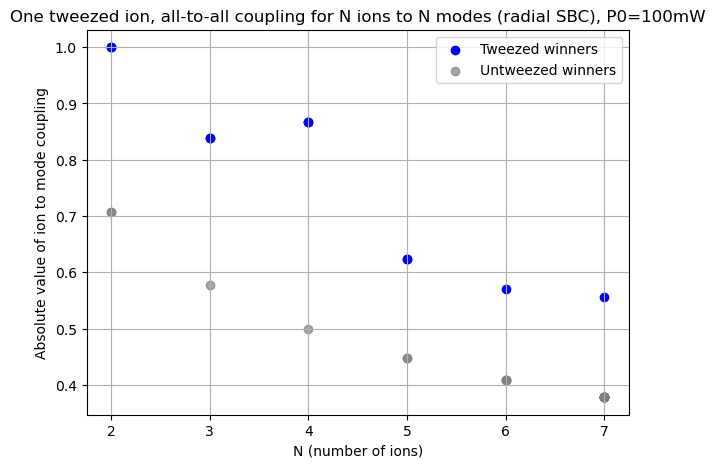

In [95]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

def _extract_score_from_win(win):
    """Return numeric score from a winner entry or None if not found."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), (best_ion, best_mode))
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def _extract_tweezed_ion(win):
    """Return tweezed ion index (or None) from a winner entry."""
    if not isinstance(win, (list, tuple)):
        return None
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 1:
        return win[0][0]
    return win[0]

# Tweezed winners only
x_tweezed = []
y_tweezed = []

for N_val, winners in results:
    if not winners:
        continue
    for win in winners:
        tweezed_ion = _extract_tweezed_ion(win)
        if tweezed_ion is None:
            continue   # skip untweezed
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_tweezed.append(N_val)
        y_tweezed.append(abs(score))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_untweezed.append(N_val)
        y_untweezed.append(abs(score))

# Convert to arrays (safe if empty)
x_tweezed = np.asarray(x_tweezed, dtype=float)
y_tweezed = np.asarray(y_tweezed, dtype=float)
x_untweezed = np.asarray(x_untweezed, dtype=float)
y_untweezed = np.asarray(y_untweezed, dtype=float)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x_tweezed, y_tweezed, color='blue', label='Tweezed winners')
plt.scatter(x_untweezed, y_untweezed, color='gray', label='Untweezed winners', alpha=0.7)

plt.xlabel("N (number of ions)")
plt.ylabel("Absolute value of ion to mode coupling")
plt.title("One tweezed ion, all-to-all coupling for N ions to N modes (radial SBC), P0=100mW")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

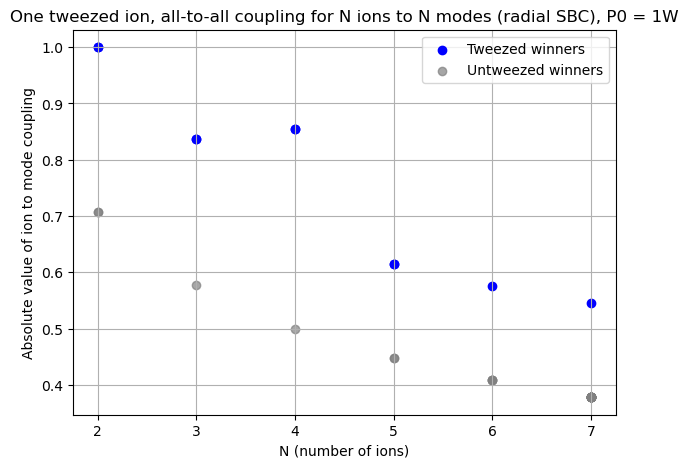

In [96]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

def _extract_score(win):
    """Return numeric score from various winner formats, or None."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), (best_ion, best_mode))
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def _extract_tweezed_ion(win):
    """Return tweezed ion index (or None) from winner entry."""
    if not isinstance(win, (list, tuple)):
        return None
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 1:
        return win[0][0]
    return win[0]  # may be None for untweezed entries

# --- Prepare data for plotting ---

# Tweezed winners (results_high_P)
x_tweezed = []
y_tweezed = []

for N_val, winners in results_high_P:
    if not winners:
        continue
    for win in winners:
        score = _extract_score(win)
        tweezed_ion = _extract_tweezed_ion(win)
        if score is None:
            continue
        # only include entries that are actually tweezed
        if tweezed_ion is None:
            continue
        x_tweezed.append(N_val)
        y_tweezed.append(abs(score))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        score = _extract_score(win)
        if score is None:
            continue
        x_untweezed.append(N_val)
        y_untweezed.append(abs(score))

# Convert to arrays (safe if empty)
x_tweezed = np.asarray(x_tweezed, dtype=float)
y_tweezed = np.asarray(y_tweezed, dtype=float)
x_untweezed = np.asarray(x_untweezed, dtype=float)
y_untweezed = np.asarray(y_untweezed, dtype=float)

# --- Plot ---
plt.figure(figsize=(7,5))
plt.scatter(x_tweezed, y_tweezed, color='blue', label='Tweezed winners')
plt.scatter(x_untweezed, y_untweezed, color='gray', label='Untweezed winners', alpha=0.7)

plt.xlabel("N (number of ions)")
plt.ylabel("Absolute value of ion to mode coupling")
plt.title("One tweezed ion, all-to-all coupling for N ions to N modes (radial SBC), P0 = 1W")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

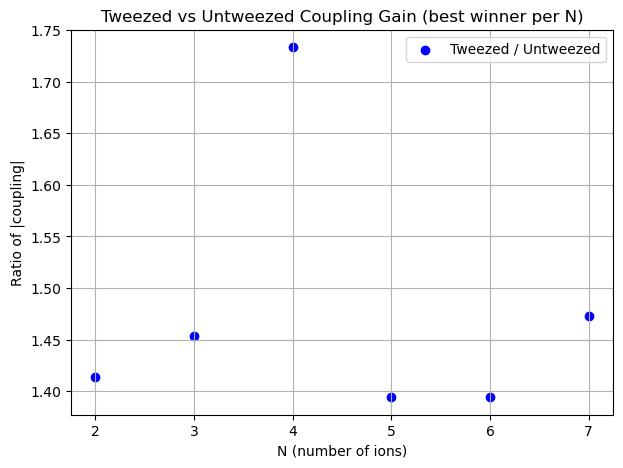

In [97]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

def _get_score_from_win(win):
    """Return numeric score from winner entry (handles nested and flat formats)."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), ...)
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def best_per_N(results):
    """Return arrays (N_values, best_abs_score) picking best winner per N robustly."""
    Ns = []
    vals = []
    for N_val, winners in results:
        if not winners:
            continue
        scores = []
        for win in winners:
            s = _get_score_from_win(win)
            if s is None:
                continue
            scores.append(s)
        if not scores:
            continue
        best_score = max(scores, key=lambda s: abs(s))
        Ns.append(N_val)
        vals.append(abs(best_score))
    return np.asarray(Ns), np.asarray(vals)

# --- Compute best-per-N for tweezed and untweezed ---
x_tweezed_best, y_tweezed_best = best_per_N(results)
x_untweezed_best, y_untweezed_best = best_per_N(untweezed_results)

# Align on common N and compute ratio (avoid divide-by-zero)
common_N = np.intersect1d(x_tweezed_best, x_untweezed_best)
if common_N.size == 0:
    print("No common N between tweezed and untweezed results — nothing to plot.")
else:
    # build lookup maps to align values
    map_t = {n: v for n, v in zip(x_tweezed_best, y_tweezed_best)}
    map_u = {n: v for n, v in zip(x_untweezed_best, y_untweezed_best)}
    common_N = np.sort(common_N)
    y_t_aligned = np.array([map_t[n] for n in common_N], dtype=float)
    y_u_aligned = np.array([map_u[n] for n in common_N], dtype=float)

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(y_u_aligned == 0, np.nan, y_t_aligned / y_u_aligned)

    # --- Plot ---
    plt.figure(figsize=(7,5))
    plt.scatter(common_N, ratio, color='blue', label='Tweezed / Untweezed')
    plt.xlabel("N (number of ions)")
    plt.ylabel("Ratio of |coupling|")
    plt.title("Tweezed vs Untweezed Coupling Gain (best winner per N)")
    plt.grid(True)
    plt.legend()
    plt.show()
# ...existing code...

## Showing the optimal configuration for N = 5


In [98]:
print(results[5-2])

(5, [((2, (2, 0, 4, 3, 1), -0.6234865428010057, [0.1]), (3, 3)), ((2, (2, 4, 0, 3, 1), -0.6234865428010057, [0.1]), (3, 3))])


In [99]:
N = 5
f_rf_r = 1e6
w_rf_a = f_rf_r/3 * 2*pi
indices = (2,0,4,3,1)
tweezed_ions = 2
w_rf_r = f_rf_r * 2 * np.pi

ueq = ion_spacing(N,w_rf_a)[0]

w0 = 1e-6
P0 = 10e-3


U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
w_tw_r = omega_tweezer_r(U,w0,m)

w_rf_combined = np.full((N,), w_rf_r)
w_rf_combined[tweezed_ions] = np.sqrt(w_tw_r**2 + w_rf_r**2)

data_N5 = mode_calc_r(m,w_rf_combined,ueq,N)
print(data_N5)




[(1001037.8417741434, array([0.44294159, 0.44737458, 0.45532129, 0.44737458, 0.44294159])), (942809.0416398385, array([-6.39533026e-01, -3.01657934e-01, -2.67932701e-12,  3.01657934e-01,
        6.39533026e-01])), (857357.0912213165, array([-0.54064761,  0.27227597,  0.51684806,  0.27227597, -0.54064761])), (732872.8354910596, array([-3.01657934e-01,  6.39533026e-01,  1.16225061e-11, -6.39533026e-01,
        3.01657934e-01])), (558895.4661621104, array([ 0.10725163, -0.47510187,  0.72494869, -0.47510187,  0.10725163]))]


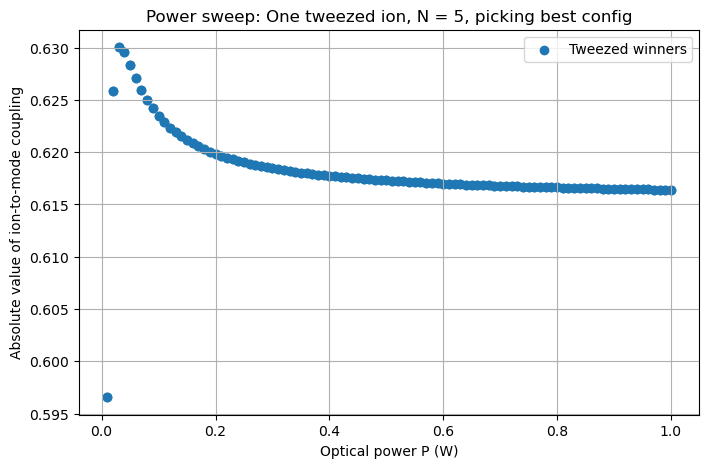

In [100]:
P_opt = np.linspace(10e-3,1,100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results_power_sweep_5 = []
for Ni in range(5, 6):
    for P_opt in P_opt:
        winners = run_optimal_mode_selection_tweezed_only(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            Ni,
            f_rf_r,
            f_rf_a,
            P_opt,
            w0,
            max_tweezed=1,
        )
        results_power_sweep_5.append((Ni, winners))

x_tweezed = []
y_tweezed = []

for P, winners in results_power_sweep_5:
    if not winners:
        continue
    for (tweezed_ion, mapping, val, P_opt), (best_ion, best_mode) in winners:
        x_tweezed.append(P_opt)  # or append P, depending on which you prefer
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, y_tweezed, marker='o', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Absolute value of ion-to-mode coupling")
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()


In [101]:
#results_power_sweep_5

## Showing the optimal configuration for N=6

In [102]:
print(results[6-2])
#print(results_high_P[6-2])
#print(untweezed_results[6-2])

(6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147804, [0.1]), (3, 4))])


In [103]:
N = 6
f_rf_r = 1e6
w_rf_a = f_rf_r/3 * 2*pi
indices = (2,5,0,4,1,3)
tweezed_ions = 2
w_rf_r = f_rf_r * 2 * np.pi

ueq = ion_spacing(N,w_rf_a)[0]

w0 = 1e-6
P0 = 1


U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
w_tw_r = omega_tweezer_r(U,w0,m)

w_rf_combined = np.full((N,), w_rf_r)
w_rf_combined[tweezed_ions] = np.sqrt(w_tw_r**2 + w_rf_r**2)

data_N6 = mode_calc_r(m,w_rf_combined,ueq,N)
print(data_N6)

[(1255704.40136543, array([0.0845683 , 0.2438689 , 0.92793597, 0.24760568, 0.09713705,
       0.03958305])), (951351.2556375064, array([-0.11404744, -0.08830807, -0.11425732,  0.22505008,  0.50855099,
        0.81047423])), (924088.6109673298, array([-0.91227995, -0.34467261,  0.17387834,  0.03560102, -0.0410669 ,
       -0.1255328 ])), (769055.9334767961, array([-0.07909169,  0.1073797 ,  0.15816996, -0.51771072, -0.61794036,
        0.55436603])), (645392.1744376079, array([ 0.37547283, -0.89317837,  0.20355198,  0.02927549, -0.12614056,
        0.05523262])), (422526.7754875689, array([-0.01874388,  0.06806193, -0.17086626,  0.78606298, -0.57662125,
        0.12423316]))]


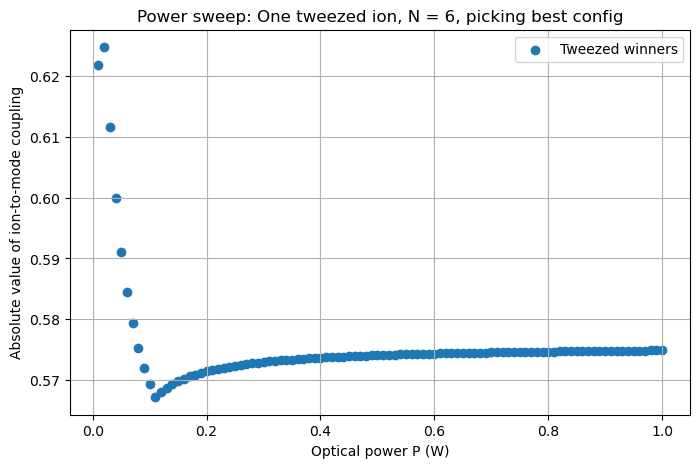

In [104]:
P_opt = np.linspace(10e-3,1,100)
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results_power_sweep_6 = []
for Ni in range(6, 7):
    for P_opt in P_opt:
        winners = run_optimal_mode_selection_tweezed_only(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            Ni,
            f_rf_r,
            f_rf_a,
            P_opt,
            w0,
            max_tweezed=1,
        )
        results_power_sweep_6.append((Ni, winners))

x_tweezed = []
y_tweezed = []

for P, winners in results_power_sweep_6:
    if not winners:
        continue
    for (tweezed_ion, mapping, val, P_opt), (best_ion, best_mode) in winners:
        x_tweezed.append(P_opt)  # or append P, depending on which you prefer
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, y_tweezed, marker='o', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Absolute value of ion-to-mode coupling")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config")
plt.grid(True)
plt.legend()
plt.show()


# Brute force calculation of 1 ion 1 tweezer for midcurcuit meas type of a setup

In [105]:
from collections import defaultdict

In [152]:
N = np.arange(3,4)
P = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N3_result= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P,
    w0,
    max_tweezed=1,
)
result_N3 = build_mode_series_and_combinations(N3_result)
mode0_list = result_N3["mode_lists"][0]
print(mode0_list)
mode1_list = result_N3["mode_lists"][1]
print(mode1_list)
mode2_list = result_N3["mode_lists"][2]
print(mode2_list)


[(nan, array([0.57735027, 0.57735027, 0.57735027])), (0, array([-0.99975899, -0.0217139 , -0.00323688])), (1, array([0.02254184, 0.99949174, 0.02254184])), (2, array([0.00323688, 0.0217139 , 0.99975899]))]
[(nan, array([ 7.07106781e-01, -1.76373406e-13, -7.07106781e-01])), (0, array([-0.01451165,  0.54298991,  0.83961382])), (1, array([ 0.70674738, -0.03187897,  0.70674738])), (2, array([-0.83961382, -0.54298991,  0.01451165]))]
[(nan, array([-0.40824829,  0.81649658, -0.40824829])), (0, array([ 0.0164737 , -0.83945844,  0.54317415])), (1, array([-7.07106781e-01, -1.83901055e-14,  7.07106781e-01])), (2, array([ 0.54317415, -0.83945844,  0.0164737 ]))]


In [153]:
result_N3["mode_lists"][0]

[(nan, array([0.57735027, 0.57735027, 0.57735027])),
 (0, array([-0.99975899, -0.0217139 , -0.00323688])),
 (1, array([0.02254184, 0.99949174, 0.02254184])),
 (2, array([0.00323688, 0.0217139 , 0.99975899]))]

In [269]:
# ...existing code...
def midcircuit_modes(omega_tweezer,
                     linewidths,
                     omega_res,
                     m,
                     mode_calc_r,
                     N,
                     f_rf_r,
                     f_rf_a,
                     P,
                     w0
                     ):
    """
    Compute combined mode lists for all tweezed configurations for given N.
    Returns a DataFrame of best rows (keeps all top-scoring rows, removes lower losers).
    Only allow selections where Tweezed Ion != Coolant Ion.
    """
    results = tweezer_combos_full_radial(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
        max_tweezed=1,
    )
    result = build_mode_series_and_combinations(results)

    mode_list_test = []
    for i in range(len(result) + 1):
        mode_list_test.append(result["mode_lists"][i])

    middle = combine_lists_same_index_df(*mode_list_test)

    # enforce condition: do not allow Tweezed Ion == Coolant Ion
    if "Tweezed Ion" in middle.columns and "Coolant Ion" in middle.columns:
        middle = middle[~(middle["Tweezed Ion"] == middle["Coolant Ion"])].reset_index(drop=True)

    # collect best per tweezed-ion group (choose canonical one per group)
    best_rows = middle.iloc[0:0].copy()
    tweezed_keys = [k for k in middle["Tweezed Ion"].unique() if pd.notna(k)]
    for key in tweezed_keys:
        subset = middle[middle["Tweezed Ion"] == key]
        if subset.empty:
            continue
        # additionally ensure no coolant == tweezed (redundant but safe)
        subset = subset[subset["Coolant Ion"] != key]
        if subset.empty:
            continue
        mn = subset["sum_inverse_middle"].abs().min()
        mask = np.isclose(subset["sum_inverse_middle"].abs(), mn, rtol=1e-12, atol=1e-12)
        tied = subset.loc[mask]
        # pick canonical representative (first by Coolant Ion) for this group
        chosen = tied.sort_values("Coolant Ion").iloc[0:1]
        best_rows = pd.concat([best_rows, chosen], ignore_index=True)

    # keep only the globally best score(s) across all tweezed groups
    if best_rows.empty:
        return best_rows

    global_max = best_rows["sum_inverse_middle"].abs().max()
    keep_mask = np.isclose(best_rows["sum_inverse_middle"].abs(), global_max, rtol=1e-8, atol=1e-12)
    final = best_rows.loc[keep_mask].reset_index(drop=True)

    # final safety filter in case any sneaked through
    if "Tweezed Ion" in final.columns and "Coolant Ion" in final.columns:
        final = final[~(final["Tweezed Ion"] == final["Coolant Ion"])].reset_index(drop=True)

    return final
# ...existing code...

In [270]:
test


,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,0.0,1,"[-0.02171389850257122, 0.542989909301837, -0.8394584355453282]","[46.05345280957201, 1.8416548500611647, 1.19124420895286]",49.086352
1,2.0,1,"[0.02171389850257437, -0.5429899093017705, -0.8394584355453685]","[46.05345280956533, 1.8416548500613903, 1.191244208952803]",49.086352


In [271]:
dfs = []
many_N = []

for N in range(9, 10):
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)

# Do NOT display the per-N DataFrames; only show the combined result
if dfs:
    combined_df = pd.concat(dfs, ignore_index=True, sort=False)
    cols = ['N', 'Tweezed Ion', 'Coolant Ion', 'Mode couplings', 'inverse_mode_couplings', 'sum_inverse_middle']
    combined_df = combined_df[[c for c in cols if c in combined_df.columns]]
else:
    combined_df = pd.DataFrame()

print("Combined DataFrame rows:", len(combined_df))
display(combined_df)
# ...existing code...

Combined DataFrame rows: 2


,N,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,9,2,1,"[-0.09788109923612244, -0.02447538960049329, -0.3856874299346666]","[10.216477009393412, 40.85736800609889, 2.5927731172607693]",53.666618
1,9,6,7,"[0.097881099236912, -0.024475389600252292, -0.3856874299216197]","[10.216477009311001, 40.85736800650119, 2.5927731173484765]",53.666618


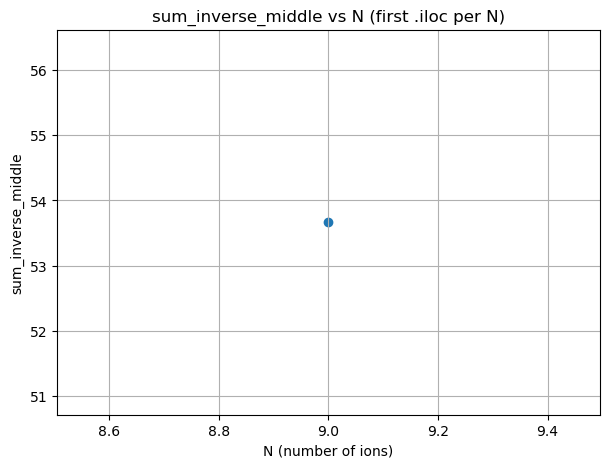

In [272]:
# pick first .iloc per N and plot sum_inverse_middle vs N
try:
    df = combined_df
except NameError:
    try:
        df = combined_df
    except NameError:
        raise NameError("combined_df or combined not found in the notebook namespace")

if df is None or (isinstance(df, (pd.DataFrame)) and df.empty):
    print("No data available in combined_df/combined to plot.")
else:
    # groupby N and take the first row for each N (preserves first .iloc order)
    first_per_N = df.groupby("N", sort=True, as_index=False).first()
    Ns = first_per_N["N"].to_numpy()
    vals = first_per_N["sum_inverse_middle"].to_numpy()

    plt.figure(figsize=(7,5))
    plt.scatter(Ns, vals, marker="o", linestyle="-")
    plt.xlabel("N (number of ions)")
    plt.ylabel("sum_inverse_middle")
    plt.title("sum_inverse_middle vs N (first .iloc per N)")
    plt.grid(True)
    plt.show()

In [281]:
# ...existing code...
from IPython.display import display
import pandas as pd
import numpy as np

def collect_midcircuit_combined_df(
    Ns,
    omega_t,
    linewidths_,
    omega_res_,
    m_,
    mode_calc,
    f_rf_r_,
    f_rf_a_,
    P_,
    w0_,
    return_many_N=False,
):
    """
    Run midcircuit_modes for each N in Ns and return a combined DataFrame.
    Does NOT print or display per-N results. Keeps all rows (no per-N dedupe).
    If return_many_N is True, also return the list of (N, per-N DataFrame).
    """
    dfs = []
    many_N = []

    for N in Ns:
        test_loop = midcircuit_modes(
            omega_t,
            linewidths_,
            omega_res_,
            m_,
            mode_calc,
            N,
            f_rf_r_,
            f_rf_a_,
            P_,
            w0_,
        )
        many_N.append((N, test_loop))

        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df["N"] = int(N)
            try:
                df["Tweezed Ion"] = df["Tweezed Ion"].astype(int)
            except Exception:
                pass
            dfs.append(df)

    if dfs:
        combined_df = pd.concat(dfs, ignore_index=True, sort=False)
        cols = [
            "N",
            "Tweezed Ion",
            "Coolant Ion",
            "Mode couplings",
            "inverse_mode_couplings",
            "sum_inverse_middle",
        ]
        combined_df = combined_df[[c for c in cols if c in combined_df.columns]]
    else:
        combined_df = pd.DataFrame()

    if return_many_N:
        return combined_df, many_N
    return combined_df

# Example:
combined = collect_midcircuit_combined_df(
    Ns=range(3,30),
    omega_t=omega_tweezer,
    linewidths_=linewidths,
    omega_res_=omega_res,
    m_=m,
    mode_calc=mode_calc_r,
    f_rf_r_=f_rf_r,
    f_rf_a_=f_rf_a,
    P_=P,
    w0_=w0,
)
# combined, perN = collect_midcircuit_combined_df(Ns=[3,4], return_many_N=True)
# ...existing code...

In [282]:
combined

,N,Tweezed Ion,Coolant Ion,Mode couplings,inverse_mode_couplings,sum_inverse_middle
0,3,0,1,"[-0.02171389850257122, 0.542989909301837, -0.8394584355453282]","[46.05345280957201, 1.8416548500611647, 1.19124420895286]",49.086352
1,3,2,1,"[0.02171389850257437, -0.5429899093017705, -0.8394584355453685]","[46.05345280956533, 1.8416548500613903, 1.191244208952803]",49.086352
2,4,1,0,"[0.03023686522953205, -0.13575600617315947, -0.989417759950597]","[33.07221143491124, 7.366156593649936, 1.0106954215678636]",41.449063
3,4,2,3,"[0.03023686522950337, 0.13575600617348638, 0.9894177599505299]","[33.07221143494261, 7.366156593632198, 1.0106954215679322]",41.449063
4,5,1,0,"[-0.037273151715348195, -0.07857382886738179, -0.9933425887526547]","[26.828962778273024, 12.726883930880046, 1.0067020294133417]",40.562549
5,5,3,4,"[0.037273151714494634, 0.07857382887014966, 0.9933425887528493]","[26.82896277888741, 12.726883930431725, 1.0067020294131446]",40.562549
6,6,1,2,"[-0.06003521236147707, -0.24606318028002, -0.06422752413987867]","[16.656891192104325, 4.063996892432259, 15.569648891060135]",36.290537
7,6,4,3,"[-0.06003521236160247, 0.24606318028041746, 0.06422752413219661]","[16.65689119206953, 4.063996892425695, 15.569648892922373]",36.290537
8,7,2,1,"[-0.07560055936293666, 0.051302627254311096, -0.4062874196719614]","[13.227415358123027, 19.492179124529482, 2.461311750207292]",35.180906
9,7,4,5,"[0.07560055936325577, 0.05130262725447711, 0.4062874196646351]","[13.227415358067194, 19.492179124466407, 2.4613117502516753]",35.180906


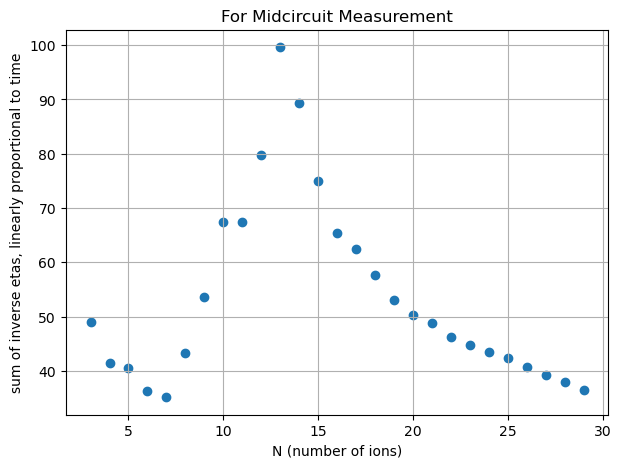

In [283]:
# pick first .iloc per N and plot sum_inverse_middle vs N
try:
    df = combined
except NameError:
    try:
        df = combined
    except NameError:
        raise NameError("combined_df or combined not found in the notebook namespace")

if df is None or (isinstance(df, (pd.DataFrame)) and df.empty):
    print("No data available in combined_df/combined to plot.")
else:
    # groupby N and take the first row for each N (preserves first .iloc order)
    first_per_N = df.groupby("N", sort=True, as_index=False).first()
    Ns = first_per_N["N"].to_numpy()
    vals = first_per_N["sum_inverse_middle"].to_numpy()

    plt.figure(figsize=(7,5))
    plt.scatter(Ns, vals, marker="o", linestyle="-")
    plt.xlabel("N (number of ions)")
    plt.ylabel("sum of inverse etas, linearly proportional to time")
    plt.title("For Midcircuit Measurement")
    plt.grid(True)
    plt.show()